In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("..")

DATA_DIR = ROOT / "data"
RUNS_DIR = ROOT / "runs"

TEST_PATH = DATA_DIR / "test.csv"
BASELINE_PATH = DATA_DIR / "submission_baseline.csv"
SUBMISSION_PATH = RUNS_DIR / "submission_final.csv"

print("TEST_PATH:", TEST_PATH.exists(), TEST_PATH)
print("BASELINE_PATH:", BASELINE_PATH.exists(), BASELINE_PATH)
print("SUBMISSION_PATH:", SUBMISSION_PATH.exists(), SUBMISSION_PATH)

TEST_PATH: True /content/test.csv
BASELINE_PATH: True /content/submission_baseline.csv
SUBMISSION_PATH: True /content/submission_final.csv


In [2]:
test_df = pd.read_csv(TEST_PATH)
baseline_df = pd.read_csv(BASELINE_PATH)
submission_df = pd.read_csv(SUBMISSION_PATH)

print("test:", test_df.shape)
print("baseline:", baseline_df.shape)
print("submission:", submission_df.shape)

test_df.head()

test: (2405, 3)
baseline: (2405, 2)
submission: (2405, 2)


,id,n,permutation
0,0,5,"3,2,0,1,4"
1,1,5,"4,2,3,1,0"
2,2,5,"3,1,2,0,4"
3,3,5,"1,2,0,3,4"
4,4,5,"3,0,4,2,1"


In [3]:
def parse_permutation(raw: str):
    if raw is None:
        return []
    raw = str(raw).strip()
    if raw == "":
        return []
    return [int(tok) for tok in raw.split(",") if tok.strip() != ""]


def moves_len(solution) -> int:
    if solution is None or (isinstance(solution, float) and pd.isna(solution)):
        return 0

    s = str(solution).strip()
    if s == "":
        return 0

    return s.count(".") + 1


test_df["n"] = test_df["permutation"].apply(lambda x: len(parse_permutation(x)))
baseline_df["baseline_len"] = baseline_df["solution"].apply(moves_len)
submission_df["solution_len"] = submission_df["solution"].apply(moves_len)

In [4]:
results_df = (
    test_df[["id", "permutation", "n"]]
    .merge(baseline_df[["id", "baseline_len"]], on="id", how="left")
    .merge(submission_df[["id", "solution", "solution_len"]], on="id", how="left")
)

results_df["gain"] = results_df["baseline_len"] - results_df["solution_len"]

results_df.head()

,id,permutation,n,baseline_len,solution,solution_len,gain
0,0,"3,2,0,1,4",5,2,R4.R2,2,0
1,1,"4,2,3,1,0",5,5,R2.R3.R2.R5,4,1
2,2,"3,1,2,0,4",5,4,R4.R2.R3.R2,4,0
3,3,"1,2,0,3,4",5,2,R2.R3,2,0
4,4,"3,0,4,2,1",5,4,R3.R5.R3.R4,4,0


In [5]:
summary = {
    "n_cases": len(results_df),
    "baseline_total": int(results_df["baseline_len"].sum()),
    "solution_total": int(results_df["solution_len"].sum()),
    "total_gain": int(results_df["gain"].sum()),
    "improved_cases": int((results_df["gain"] > 0).sum()),
    "same_cases": int((results_df["gain"] == 0).sum()),
    "worse_cases": int((results_df["gain"] < 0).sum()),
    "improved_frac": float((results_df["gain"] > 0).mean()),
    "mean_gain": float(results_df["gain"].mean()),
    "max_gain": int(results_df["gain"].max()),
}

summary

{'n_cases': 2405,
 'baseline_total': 158680,
 'solution_total': 92077,
 'total_gain': 66603,
 'improved_cases': 2401,
 'same_cases': 4,
 'worse_cases': 0,
 'improved_frac': 0.9983367983367983,
 'mean_gain': 27.693555093555094,
 'max_gain': 91}

In [10]:
print("Улучшено:", summary["improved_cases"])
print("Совпало:", summary["same_cases"])
print("Ухудшено:", summary["worse_cases"])
print("Доля улучшений:", round(summary["improved_frac"], 4))

Улучшено: 2401
Совпало: 4
Ухудшено: 0
Доля улучшений: 0.9983


## Основные результаты

На полном тестовом наборе итоговое решение сравнивается с классическим baseline-алгоритмом pancake sorting.

Итоговый подход улучшает baseline почти во всех случаях и не ухудшает решение ни на одном примере. Особенно заметный выигрыш наблюдается на больших перестановках.

In [6]:
gain_by_n = (
    results_df
    .groupby("n", as_index=False)
    .agg(
        mean_gain=("gain", "mean"),
        mean_baseline_len=("baseline_len", "mean"),
        mean_solution_len=("solution_len", "mean"),
        improved_cases=("gain", lambda x: (x > 0).sum()),
        cases=("gain", "size"),
    )
)

gain_by_n

,n,mean_gain,mean_baseline_len,mean_solution_len,improved_cases,cases
0,5,0.200,3.400,3.200,1,5
1,12,4.990,15.820,10.830,200,200
2,15,7.395,21.130,13.735,200,200
3,16,7.975,22.780,14.805,200,200
4,20,11.590,30.460,18.870,200,200
5,25,15.390,39.615,24.225,200,200
6,30,20.315,49.550,29.235,200,200
7,35,24.495,58.750,34.255,200,200
8,40,29.025,68.470,39.445,200,200
9,45,32.800,77.450,44.650,200,200


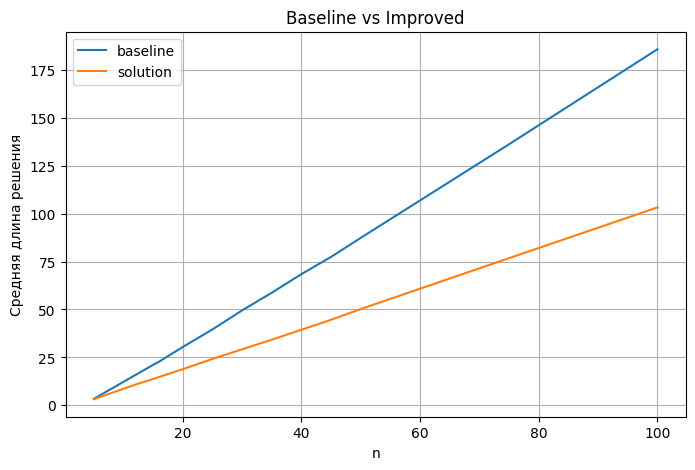

In [16]:
plt.figure(figsize=(8,5))
plt.plot(gain_by_n["n"], gain_by_n["mean_baseline_len"], label="baseline")
plt.plot(gain_by_n["n"], gain_by_n["mean_solution_len"], label="solution")
plt.legend()
plt.xlabel("n")
plt.ylabel("Средняя длина решения")
plt.title("Baseline vs Improved")
plt.grid()
plt.show()

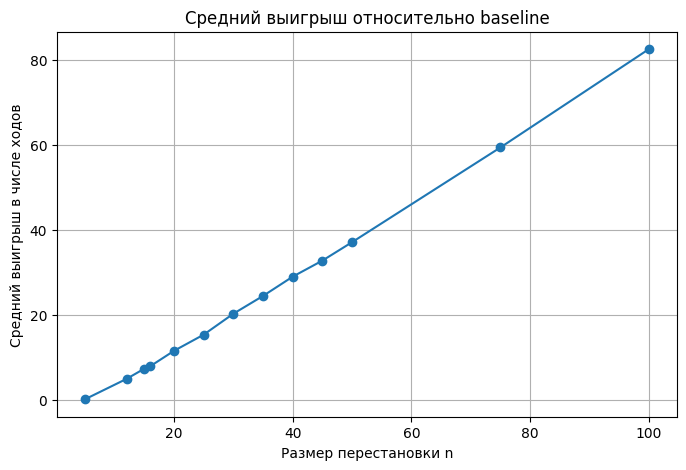

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(gain_by_n["n"], gain_by_n["mean_gain"], marker="o")
plt.xlabel("Размер перестановки n")
plt.ylabel("Средний выигрыш в числе ходов")
plt.title("Средний выигрыш относительно baseline")
plt.grid(True)
plt.show()

### Масштабируемость метода

Средний выигрыш растёт почти линейно с увеличением размера перестановки.

- при n ≈ 10 → выигрыш ~5 шагов  
- при n ≈ 50 → ~35 шагов  
- при n = 100 → **~80+ шагов**

Чем сложнее задача, тем сильнее преимущество метода над baseline.

Классический pancake sorting становится всё менее эффективным при росте n.

Предложенный подход:
- использует структуру пространства состояний
- находит более короткие пути
- особенно эффективен на больших n

In [8]:
results_df.sort_values("gain", ascending=False).head(10)[
    ["id", "n", "baseline_len", "solution_len", "gain", "permutation", "solution"]
]

,id,n,baseline_len,solution_len,gain,permutation,solution
2342,2342,100,194,103,91,"25,67,77,27,10,12,97,94,18,19,58,30,43,36,88,6...",R69.R94.R91.R59.R75.R96.R16.R5.R62.R7.R18.R38....
2210,2210,100,195,104,91,"98,1,21,49,20,42,89,41,93,6,85,97,79,61,33,3,7...",R52.R90.R69.R39.R26.R76.R43.R27.R87.R91.R97.R6...
2382,2382,100,193,102,91,"10,4,52,14,0,50,51,21,36,94,98,54,60,77,56,86,...",R94.R58.R22.R69.R29.R85.R13.R69.R66.R71.R90.R5...
2358,2358,100,186,96,90,"74,75,9,32,84,64,96,72,71,63,19,43,94,95,42,7,...",R19.R36.R66.R60.R73.R85.R48.R65.R33.R91.R55.R3...
2291,2291,100,195,105,90,"23,45,13,12,14,43,56,53,38,52,1,75,86,47,20,69...",R90.R84.R82.R51.R60.R86.R42.R81.R32.R26.R80.R4...
2394,2394,100,193,103,90,"8,66,69,15,28,53,78,35,43,52,50,58,67,92,65,9,...",R26.R66.R5.R88.R96.R17.R86.R13.R75.R59.R64.R45...
2216,2216,100,192,102,90,"17,22,71,9,88,30,7,10,19,67,31,57,47,75,70,76,...",R20.R56.R29.R21.R65.R34.R27.R92.R36.R7.R63.R13...
2390,2390,100,191,101,90,"54,83,6,11,28,34,61,24,56,97,25,15,63,27,67,80...",R63.R13.R35.R21.R42.R82.R34.R52.R57.R79.R91.R9...
2247,2247,100,191,102,89,"24,4,77,90,32,68,5,12,28,98,36,89,61,0,39,43,6...",R71.R20.R74.R94.R2.R83.R55.R85.R76.R69.R22.R13...
2400,2400,100,192,103,89,"47,85,55,96,30,63,54,34,80,69,50,78,14,36,99,6...",R70.R36.R27.R60.R12.R35.R77.R95.R70.R33.R76.R8...


In [11]:
best = results_df.sort_values("gain", ascending=False).iloc[0]

print("Permutation:", best["permutation"])
print("Baseline length:", best["baseline_len"])
print("Solution length:", best["solution_len"])
print("Gain:", best["gain"])
print("Solution:", best["solution"])

Permutation: 25,67,77,27,10,12,97,94,18,19,58,30,43,36,88,64,59,49,84,82,76,9,70,78,11,26,85,7,23,29,20,57,0,56,21,40,54,55,65,8,91,28,46,62,86,1,16,90,33,41,15,87,73,69,2,3,99,32,42,66,37,22,61,35,95,98,14,80,48,24,83,63,60,38,79,39,17,74,93,71,89,81,52,4,45,50,31,34,5,92,68,96,72,13,47,51,75,44,6,53
Baseline length: 194
Solution length: 103
Gain: 91
Solution: R69.R94.R91.R59.R75.R96.R16.R5.R62.R7.R18.R38.R36.R11.R94.R86.R67.R83.R37.R67.R52.R7.R55.R27.R32.R34.R47.R69.R79.R12.R36.R27.R60.R30.R93.R76.R54.R19.R16.R58.R34.R18.R57.R73.R32.R14.R85.R24.R86.R46.R41.R98.R90.R12.R46.R50.R53.R52.R17.R18.R56.R84.R33.R8.R94.R15.R22.R88.R59.R51.R65.R4.R74.R33.R92.R28.R99.R29.R78.R14.R65.R32.R59.R6.R87.R65.R8.R10.R63.R51.R97.R77.R59.R77.R65.R26.R74.R47.R100.R50.R41.R96.R100


### Пример сильного улучшения

Одна из перестановок:

- baseline: **194 шага**
- найденное решение: **103 шага**
- выигрыш: **91 шаг**

почти в **2 раза короче**